# DLA vs EAP-IG — Method Comparison for Paper

Comparison of Direct Logit Attribution (DLA) and Edge Attribution Patching with
Integrated Gradients (EAP-IG-activations) against Activation Patching (AP)
ground truth, across **three models** and **two ablation modes** (zero, mean).

All figures export to `outputs/figures/eap_ig_comparison/*.pdf`.

In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# ── Paper-ready style ────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "font.family": "serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

CB_BLUE = "#0072B2"
CB_ORANGE = "#E69F00"
CB_GREEN = "#009E73"
CB_GREY = "#999999"

METHOD_COLORS = {"DLA": CB_BLUE, "EAP-IG": CB_ORANGE}
METHOD_HATCHES = {"DLA": "", "EAP-IG": "//"}

MODELS = ["gpt2-xl", "meta-llama/Llama-3.2-1B", "google/gemma-2-2b"]
MODEL_SHORT = {m: m.split("/")[-1] for m in MODELS}
MODES = ["zero", "mean"]
METHODS = ["DLA", "EAP-IG"]

MERGE_KEYS = [
    "model", "example_id", "candidate", "candidate_type",
    "target_token_id", "layer", "component_type", "head_idx",
]

OUTPUT_DIR = Path("../../outputs/dla_error_analysis")
FIG_DIR = Path("../../outputs/figures/eap_ig_comparison")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Load summaries ───────────────────────────────────────────────────
with open(OUTPUT_DIR / "summary_all_models.json") as f:
    dla_summary_list = json.load(f)
dla_summary_df = pd.DataFrame(dla_summary_list)

with open(OUTPUT_DIR / "summary_all_models_eap_ig.json") as f:
    eap_summary_list = json.load(f)
eap_summary_df = pd.DataFrame(eap_summary_list)

# ── Load and merge records ───────────────────────────────────────────
record_dfs = {}
for model in MODELS:
    safe = model.replace("/", "_")
    for mode in MODES:
        ap_path = OUTPUT_DIR / f"{safe}_{mode}_ablation_records.csv"
        eap_path = OUTPUT_DIR / f"{safe}_eap_ig_{mode}_ablation_records.csv"
        if not ap_path.exists() or not eap_path.exists():
            print(f"[SKIP] Missing file for {model} ({mode})")
            continue
        df_ap = pd.read_csv(ap_path)
        df_eap = pd.read_csv(eap_path)
        merged = df_ap.merge(df_eap[MERGE_KEYS + ["eap_ig"]], on=MERGE_KEYS, how="inner")
        record_dfs[(model, mode)] = merged
        print(f"  {MODEL_SHORT[model]:20s} {mode:5s} — {len(merged):,} merged records")


def nmae_against(a, b, denom_source):
    denom = np.sum(np.abs(denom_source))
    return float(np.sum(np.abs(a - b)) / denom * 100.0) if denom else float("inf")


def save(fig, name):
    fig.savefig(FIG_DIR / name, format="pdf", bbox_inches="tight")
    print(f"  -> {FIG_DIR / name}")


print(f"\nRecord DFs loaded: {len(record_dfs)}")
print(f"DLA summary rows : {len(dla_summary_df)}")
print(f"EAP summary rows : {len(eap_summary_df)}")

  gpt2-xl              zero  — 374,400 merged records
  gpt2-xl              mean  — 374,400 merged records
  Llama-3.2-1B         zero  — 158,400 merged records
  Llama-3.2-1B         mean  — 158,400 merged records
  gemma-2-2b           zero  — 70,200 merged records
  gemma-2-2b           mean  — 70,200 merged records

Record DFs loaded: 6
DLA summary rows : 6
EAP summary rows : 6


## 2. Headline NMAE — DLA vs EAP-IG vs AP

  -> ../../outputs/figures/eap_ig_comparison/fig_headline_nmae.pdf


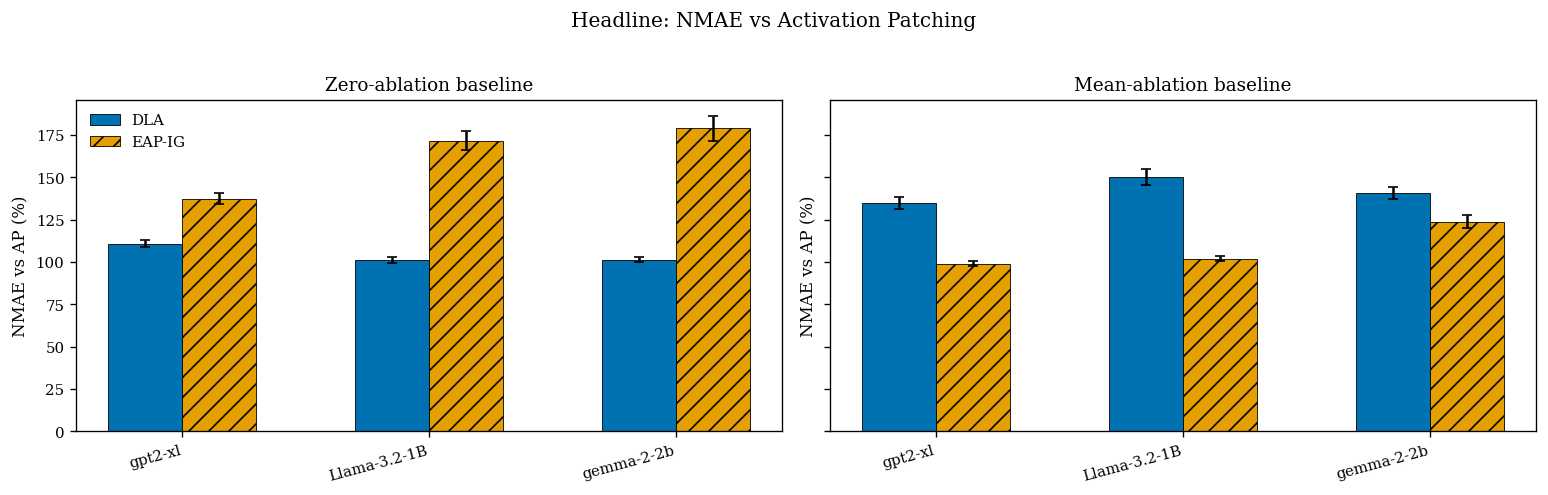

In [7]:
# Section 2 — Headline NMAE: DLA vs EAP-IG (both vs AP)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
bar_w = 0.30

for ax_i, mode in enumerate(MODES):
    ax = axes[ax_i]
    x = np.arange(len(MODELS))

    for j, method in enumerate(METHODS):
        vals, ci_lo, ci_hi = [], [], []
        for model in MODELS:
            erow = eap_summary_df[
                (eap_summary_df["model"] == model)
                & (eap_summary_df["ablation_type"] == mode)
            ].iloc[0]
            if method == "DLA":
                drow = dla_summary_df[
                    (dla_summary_df["model"] == model)
                    & (dla_summary_df["ablation_type"] == mode)
                ].iloc[0]
                vals.append(drow["total_dla_error_nmae"])
                ci_lo.append(drow["total_ci_lo"])
                ci_hi.append(drow["total_ci_hi"])
            else:
                vals.append(erow["eap_ig_vs_ap_nmae"])
                ci_lo.append(erow["eap_ig_vs_ap_ci_lo"])
                ci_hi.append(erow["eap_ig_vs_ap_ci_hi"])

        vals = np.array(vals)
        errs = np.array([vals - ci_lo, np.array(ci_hi) - vals])

        bars = ax.bar(
            x + j * bar_w, vals, bar_w,
            yerr=errs, capsize=3,
            color=METHOD_COLORS[method],
            hatch=METHOD_HATCHES[method],
            edgecolor="black", linewidth=0.5,
            label=method,
        )

    ax.set_xticks(x + bar_w / 2)
    ax.set_xticklabels([MODEL_SHORT[m] for m in MODELS], rotation=15, ha="right")
    ax.set_title(f"{mode.title()}-ablation baseline")
    ax.set_ylabel("NMAE vs AP (%)")

axes[0].legend(frameon=False)
fig.suptitle("Headline: NMAE vs Activation Patching", fontsize=12, y=1.02)
fig.tight_layout()
save(fig, "fig_headline_nmae.pdf")
plt.show()

## 3. Ablation-mode crossover

  -> ../../outputs/figures/eap_ig_comparison/fig_ablation_crossover.pdf


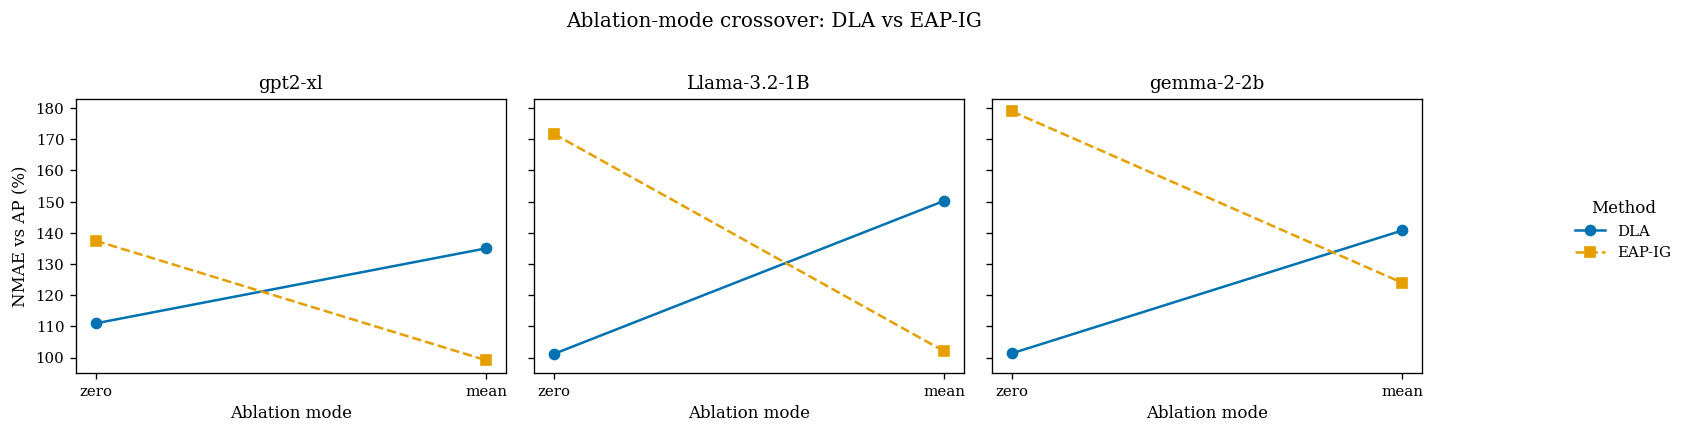

In [8]:
# Section 3 — Ablation-mode crossover
fig, axes = plt.subplots(1, len(MODELS), figsize=(13, 3.5), sharey=True)
linestyles = {"DLA": "-", "EAP-IG": "--"}
markers = {"DLA": "o", "EAP-IG": "s"}

for ax_i, model in enumerate(MODELS):
    ax = axes[ax_i]
    for method in METHODS:
        y_vals = []
        for mode in MODES:
            erow = eap_summary_df[
                (eap_summary_df["model"] == model)
                & (eap_summary_df["ablation_type"] == mode)
            ].iloc[0]
            if method == "DLA":
                drow = dla_summary_df[
                    (dla_summary_df["model"] == model)
                    & (dla_summary_df["ablation_type"] == mode)
                ].iloc[0]
                y_vals.append(drow["total_dla_error_nmae"])
            else:
                y_vals.append(erow["eap_ig_vs_ap_nmae"])

        ax.plot(MODES, y_vals,
                color=METHOD_COLORS[method],
                linestyle=linestyles[method],
                marker=markers[method], markersize=6,
                label=method)
    ax.set_title(MODEL_SHORT[model])
    ax.set_xlabel("Ablation mode")
    if ax_i == 0:
        ax.set_ylabel("NMAE vs AP (%)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.005, 0.5),
           frameon=False, title="Method")
fig.suptitle("Ablation-mode crossover: DLA vs EAP-IG", fontsize=12, y=1.02)
fig.tight_layout(rect=[0, 0, 0.93, 1])
save(fig, "fig_ablation_crossover.pdf")
plt.show()

## 4. Spearman rank correlation vs AP

  -> ../../outputs/figures/eap_ig_comparison/fig_spearman.pdf


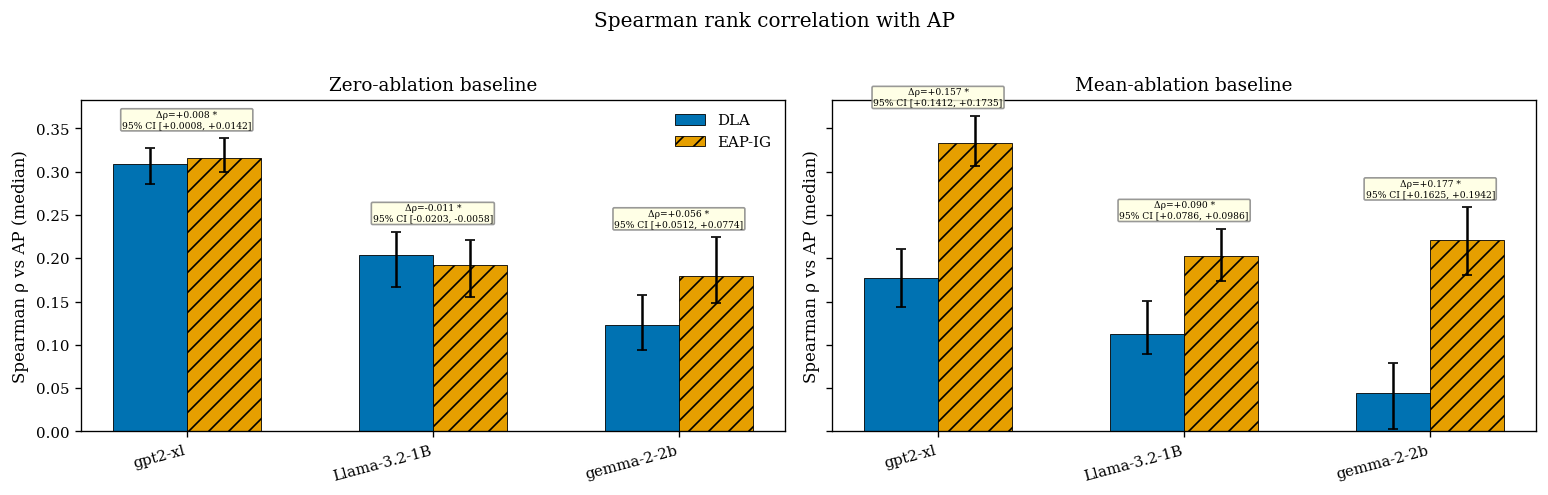

In [9]:
# Section 4 — Spearman rank correlation vs AP
# IQR is stored as [Q25, Q75] in the summary JSON
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
bar_w = 0.30

for ax_i, mode in enumerate(MODES):
    ax = axes[ax_i]
    x = np.arange(len(MODELS))
    for j, method in enumerate(METHODS):
        medians, lo_errs, hi_errs = [], [], []
        for model in MODELS:
            erow = eap_summary_df[
                (eap_summary_df["model"] == model)
                & (eap_summary_df["ablation_type"] == mode)
            ].iloc[0]
            if method == "DLA":
                med = erow["dla_spearman_median"]
                q25, q75 = erow["dla_spearman_iqr"]
            else:
                med = erow["eap_ig_spearman_median"]
                q25, q75 = erow["eap_ig_spearman_iqr"]
            medians.append(med)
            lo_errs.append(med - q25)
            hi_errs.append(q75 - med)

        medians = np.array(medians)
        errs = np.array([lo_errs, hi_errs])

        ax.bar(
            x + j * bar_w, medians, bar_w,
            yerr=errs, capsize=3,
            color=METHOD_COLORS[method],
            hatch=METHOD_HATCHES[method],
            edgecolor="black", linewidth=0.5,
            label=method,
        )

    # Annotate Δρ (bootstrap) with CI and significance above each bar pair
    for i, model in enumerate(MODELS):
        erow = eap_summary_df[
            (eap_summary_df["model"] == model)
            & (eap_summary_df["ablation_type"] == mode)
        ].iloc[0]
        if "delta_spearman_median" in erow.index:
            delta = erow["delta_spearman_median"]
            ci_lo = erow["delta_spearman_ci_lo"]
            ci_hi = erow["delta_spearman_ci_hi"]
            pval = erow["delta_spearman_pvalue"]
            sig = "*" if pval < 0.05 else "n.s."
            y_top = max(erow["eap_ig_spearman_iqr"][1],
                        erow["dla_spearman_iqr"][1])
            ax.annotate(
                f"Δρ={delta:+.3f} {sig}\n95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]",
                xy=(x[i] + bar_w / 2, y_top + 0.01),
                ha="center", va="bottom", fontsize=5.5,
                bbox=dict(boxstyle="round,pad=0.15", fc="lightyellow",
                          ec="gray", alpha=0.8),
            )

    ax.axhline(0, color="grey", linewidth=0.5, linestyle=":")
    ax.set_xticks(x + bar_w / 2)
    ax.set_xticklabels([MODEL_SHORT[m] for m in MODELS], rotation=15, ha="right")
    ax.set_title(f"{mode.title()}-ablation baseline")
    ax.set_ylabel("Spearman ρ vs AP (median)")

axes[0].legend(frameon=False)
fig.suptitle("Spearman rank correlation with AP", fontsize=12, y=1.02)
fig.tight_layout()
save(fig, "fig_spearman.pdf")
plt.show()

## 5. Selection quality — sign agreement + top-k Jaccard

  -> ../../outputs/figures/eap_ig_comparison/fig_selection_quality.pdf


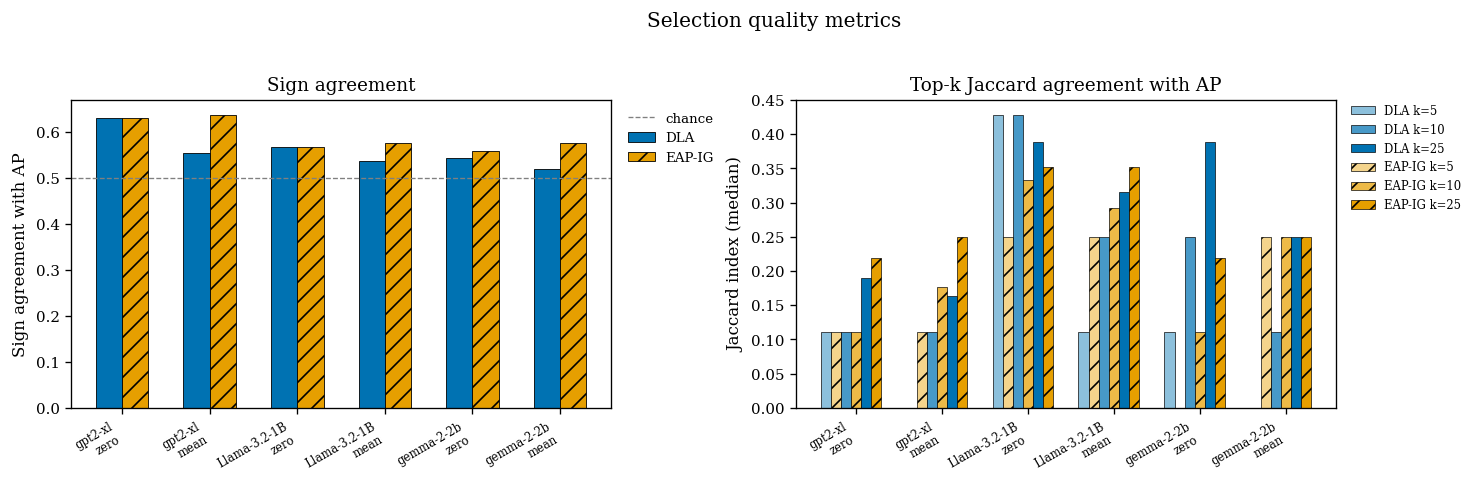

In [10]:
# Section 5 — Sign agreement + top-k Jaccard
import matplotlib.colors as mcolors

def _tint(hex_color, amount):
    """Blend hex_color toward white; amount=0 -> original, amount=1 -> white."""
    rgb = np.array(mcolors.to_rgb(hex_color))
    white = np.array([1.0, 1.0, 1.0])
    return tuple(rgb + (white - rgb) * amount)

fig, (ax_sign, ax_jacc) = plt.subplots(1, 2, figsize=(13, 4))
bar_w = 0.30

# ── Sign agreement ──
x = np.arange(len(MODELS) * len(MODES))
xlabels = [f"{MODEL_SHORT[m]}\n{mode}" for m in MODELS for mode in MODES]

for j, method in enumerate(METHODS):
    vals = []
    for model in MODELS:
        for mode in MODES:
            erow = eap_summary_df[
                (eap_summary_df["model"] == model)
                & (eap_summary_df["ablation_type"] == mode)
            ].iloc[0]
            key = "dla_sign_agreement" if method == "DLA" else "eap_ig_sign_agreement"
            vals.append(erow[key])
    ax_sign.bar(x + j * bar_w, vals, bar_w,
                color=METHOD_COLORS[method],
                hatch=METHOD_HATCHES[method],
                edgecolor="black", linewidth=0.5,
                label=method)

ax_sign.axhline(0.5, color="grey", linewidth=0.8, linestyle="--", label="chance")
ax_sign.set_xticks(x + bar_w / 2)
ax_sign.set_xticklabels(xlabels, fontsize=7, rotation=30, ha="right")
ax_sign.set_ylabel("Sign agreement with AP")
ax_sign.set_title("Sign agreement")
ax_sign.legend(frameon=False, fontsize=8, loc="upper left",
                bbox_to_anchor=(1.01, 1.0))

# ── Top-k Jaccard ──
ks = [5, 10, 25]
group_w = len(ks) * len(METHODS) * bar_w + 0.2
x_models = np.arange(len(MODELS) * len(MODES))
xlabels2 = xlabels

sub_w = 0.12
offsets = {}
idx = 0
for k in ks:
    for method in METHODS:
        offsets[(k, method)] = idx * sub_w
        idx += 1

# Encode k via shade (lighter = smaller k) and method via hue + hatch,
# so both dimensions are readable independently of each other.
K_TINTS = {5: 0.55, 10: 0.28, 25: 0.0}

for k in ks:
    for method in METHODS:
        vals = []
        for model in MODELS:
            for mode in MODES:
                erow = eap_summary_df[
                    (eap_summary_df["model"] == model)
                    & (eap_summary_df["ablation_type"] == mode)
                ].iloc[0]
                key = f"{'dla' if method == 'DLA' else 'eap_ig'}_top{k}_jaccard_median"
                vals.append(erow[key])
        ax_jacc.bar(
            x_models * (idx * sub_w + 0.3) + offsets[(k, method)],
            vals, sub_w,
            color=_tint(METHOD_COLORS[method], K_TINTS[k]),
            hatch=METHOD_HATCHES[method],
            edgecolor="black", linewidth=0.4,
            label=f"{method} k={k}" if x_models[0] == 0 else None,
        )

tick_pos = x_models * (idx * sub_w + 0.3) + (idx * sub_w) / 2
ax_jacc.set_xticks(tick_pos)
ax_jacc.set_xticklabels(xlabels2, fontsize=7, rotation=30, ha="right")
ax_jacc.set_ylabel("Jaccard index (median)")
ax_jacc.set_title("Top-k Jaccard agreement with AP")
# Order legend entries as DLA k=5,10,25, then EAP-IG k=5,10,25 so the shade
# progression (light -> dark = k=5 -> k=25) reads clearly top-to-bottom.
handles, labels = ax_jacc.get_legend_handles_labels()
def _legend_key(label):
    method_part, k_part = label.split(" k=")
    return (method_part, int(k_part))
order = sorted(range(len(labels)), key=lambda i: _legend_key(labels[i]))
ax_jacc.legend([handles[i] for i in order], [labels[i] for i in order],
               frameon=False, fontsize=7, loc="upper left",
               bbox_to_anchor=(1.01, 1.02))

fig.suptitle("Selection quality metrics", fontsize=12, y=1.02)
fig.tight_layout()
fig.subplots_adjust(right=0.86)
save(fig, "fig_selection_quality.pdf")
plt.show()

## 6. Scatter — DLA / EAP-IG vs AP per model

  -> ../../outputs/figures/eap_ig_comparison/fig_scatter_gpt2-xl.pdf


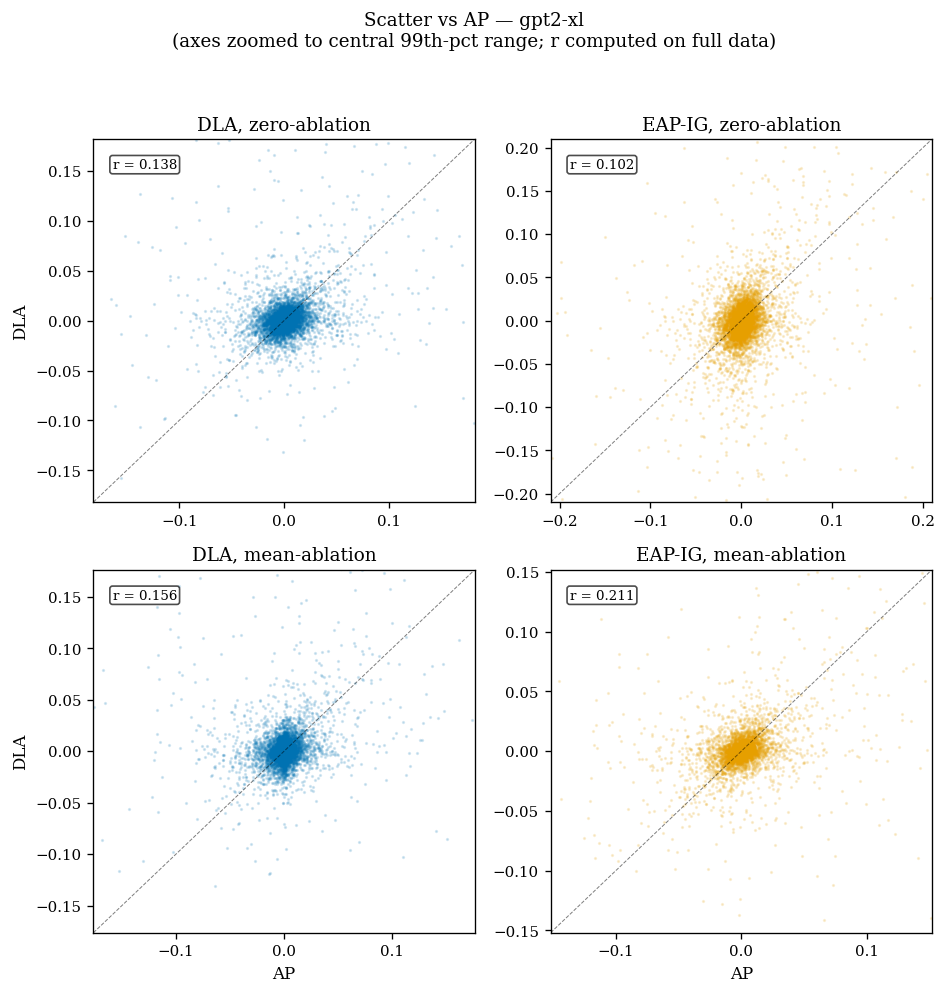

  -> ../../outputs/figures/eap_ig_comparison/fig_scatter_meta-llama_Llama-3.2-1B.pdf


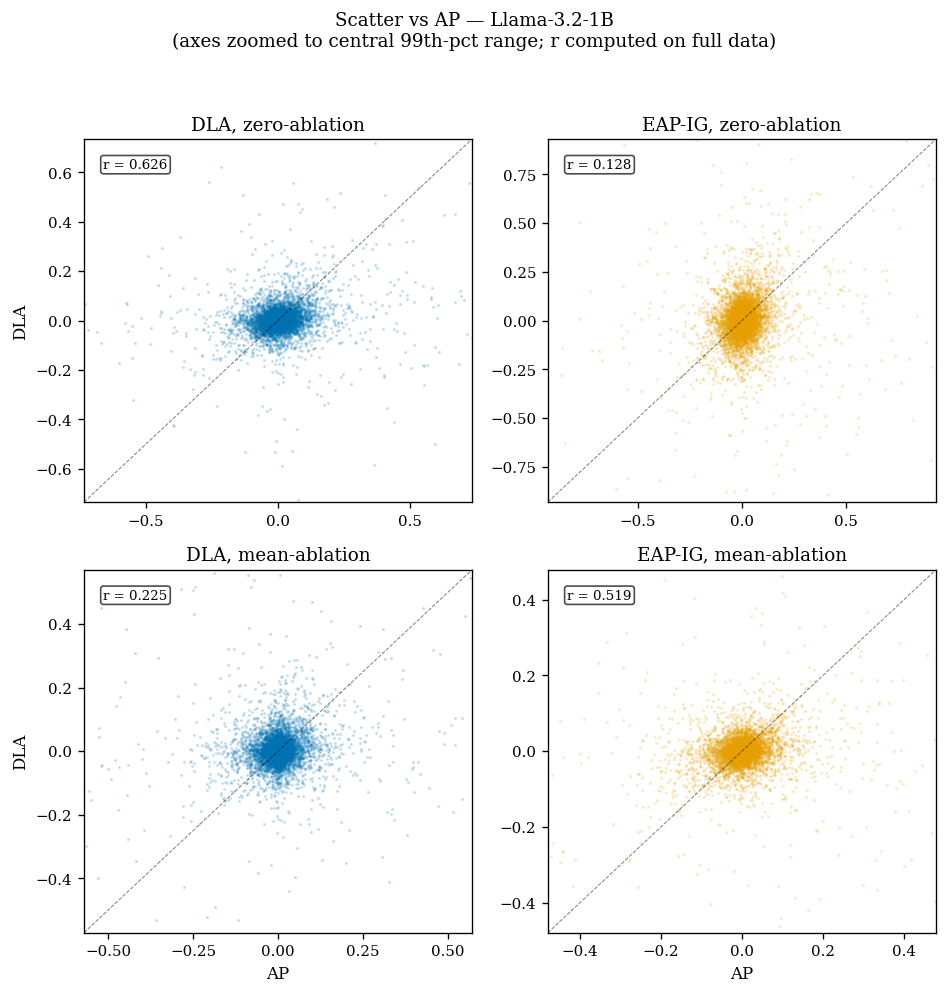

  -> ../../outputs/figures/eap_ig_comparison/fig_scatter_google_gemma-2-2b.pdf


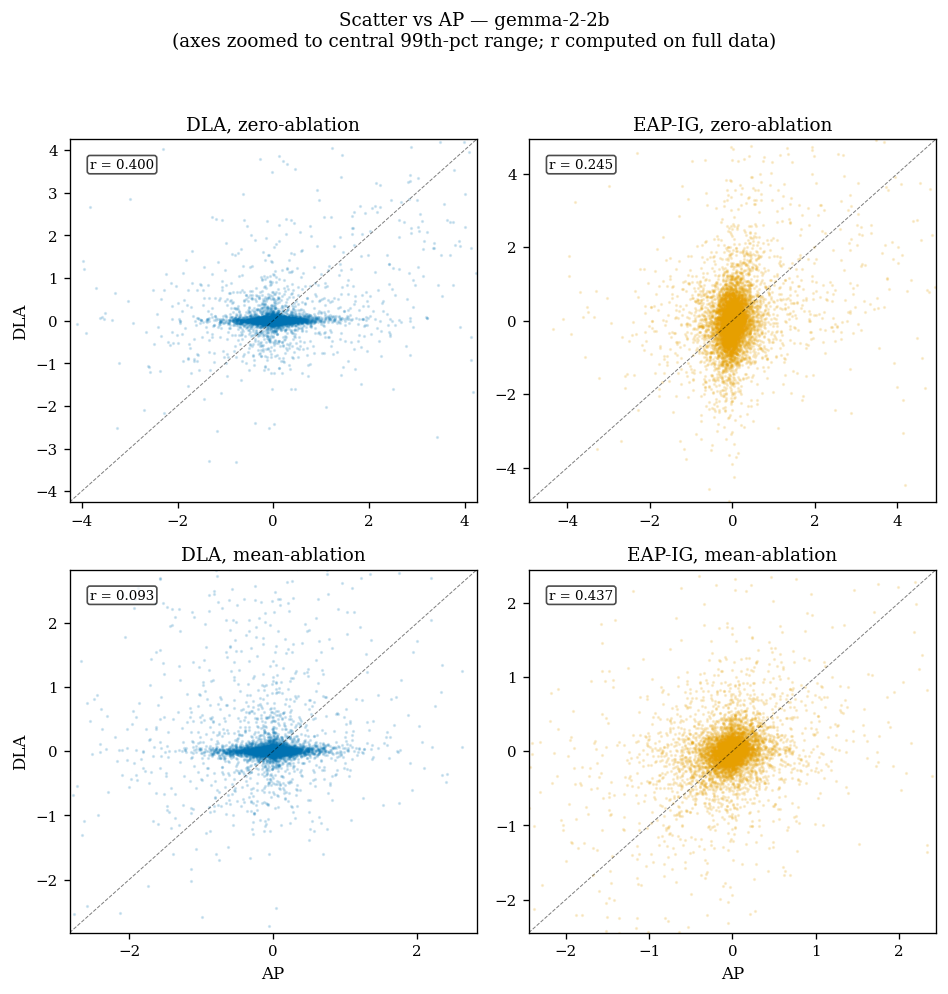

In [11]:
# Section 6 — Scatter: method vs AP per model
from scipy.stats import pearsonr

MAX_PTS = 10_000

for model in MODELS:
    safe = model.replace("/", "_")
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))

    for col_i, method in enumerate(["DLA", "EAP-IG"]):
        attr_col = "dla" if method == "DLA" else "eap_ig"
        for row_i, mode in enumerate(MODES):
            ax = axes[row_i, col_i]
            key = (model, mode)
            if key not in record_dfs:
                ax.set_visible(False)
                continue
            df = record_dfs[key]
            ap = df["ap_precap"].values
            vals = df[attr_col].values

            if len(ap) > MAX_PTS:
                idx = np.random.default_rng(42).choice(len(ap), MAX_PTS, replace=False)
                ap_s, vals_s = ap[idx], vals[idx]
            else:
                ap_s, vals_s = ap, vals

            ax.scatter(ap_s, vals_s, s=1, alpha=0.15, color=METHOD_COLORS[method])

            # Zoom to the central 99th-pct range: a handful of extreme outliers
            # otherwise stretch the axes so the dense cluster near 0 (where
            # almost all points sit) is squashed into an unreadable smear.
            lim = np.percentile(np.abs(np.concatenate([ap, vals])), 99) * 1.15
            lim = max(lim, 1e-6)
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            ax.plot([-lim, lim], [-lim, lim], "k--", linewidth=0.6, alpha=0.5)
            ax.locator_params(axis="x", nbins=5)

            r, _ = pearsonr(ap, vals)
            ax.annotate(f"r = {r:.3f}", xy=(0.05, 0.92),
                        xycoords="axes fraction", fontsize=8,
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
            ax.set_xlabel("AP" if row_i == 1 else "")
            ax.set_ylabel(method if col_i == 0 else "")
            ax.set_title(f"{method}, {mode}-ablation")

    fig.suptitle(f"Scatter vs AP — {MODEL_SHORT[model]}\n"
                 f"(axes zoomed to central 99th-pct range; r computed on full data)",
                 fontsize=11, y=1.03)
    fig.tight_layout()
    save(fig, f"fig_scatter_{safe}.pdf")
    plt.show()

## 7. Per-layer NMAE breakdown

  -> ../../outputs/figures/eap_ig_comparison/fig_per_layer_nmae.pdf


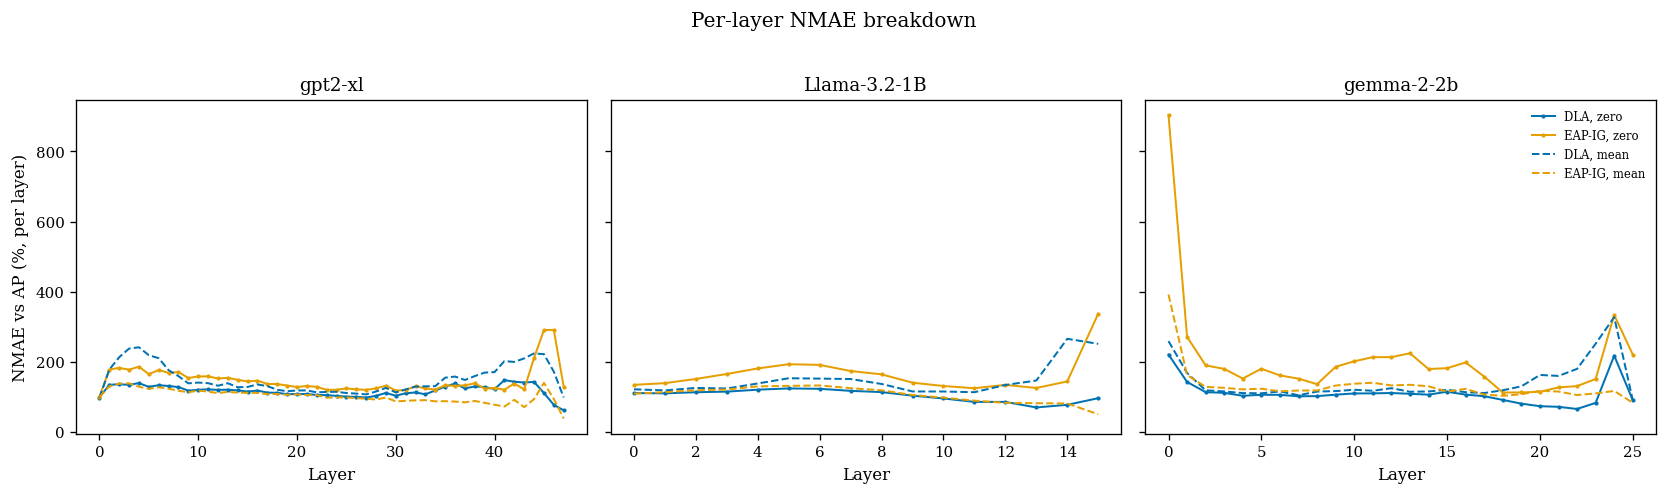

In [12]:
# Section 7 — Per-layer NMAE breakdown
fig, axes = plt.subplots(1, len(MODELS), figsize=(14, 4), sharey=True)
mode_styles = {"zero": "-", "mean": "--"}

for ax_i, model in enumerate(MODELS):
    ax = axes[ax_i]
    for mode in MODES:
        key = (model, mode)
        if key not in record_dfs:
            continue
        df = record_dfs[key]
        ap = df["ap_precap"]

        for method in METHODS:
            attr_col = "dla" if method == "DLA" else "eap_ig"
            layer_nmae = []
            layers = sorted(df["layer"].unique())
            for L in layers:
                mask = df["layer"] == L
                layer_nmae.append(nmae_against(
                    df.loc[mask, attr_col].values,
                    ap[mask].values,
                    ap[mask].values,
                ))

            ax.plot(layers, layer_nmae,
                    color=METHOD_COLORS[method],
                    linestyle=mode_styles[mode],
                    marker="." if mode == "zero" else "",
                    markersize=3, linewidth=1.2,
                    label=f"{method}, {mode}")

    ax.set_title(MODEL_SHORT[model])
    ax.set_xlabel("Layer")
    if ax_i == 0:
        ax.set_ylabel("NMAE vs AP (%, per layer)")

axes[-1].legend(frameon=False, fontsize=7, loc="best")
fig.suptitle("Per-layer NMAE breakdown", fontsize=12, y=1.02)
fig.tight_layout()
save(fig, "fig_per_layer_nmae.pdf")
plt.show()

## 8. Component-type breakdown — heads vs MLPs

  -> ../../outputs/figures/eap_ig_comparison/fig_component_type.pdf


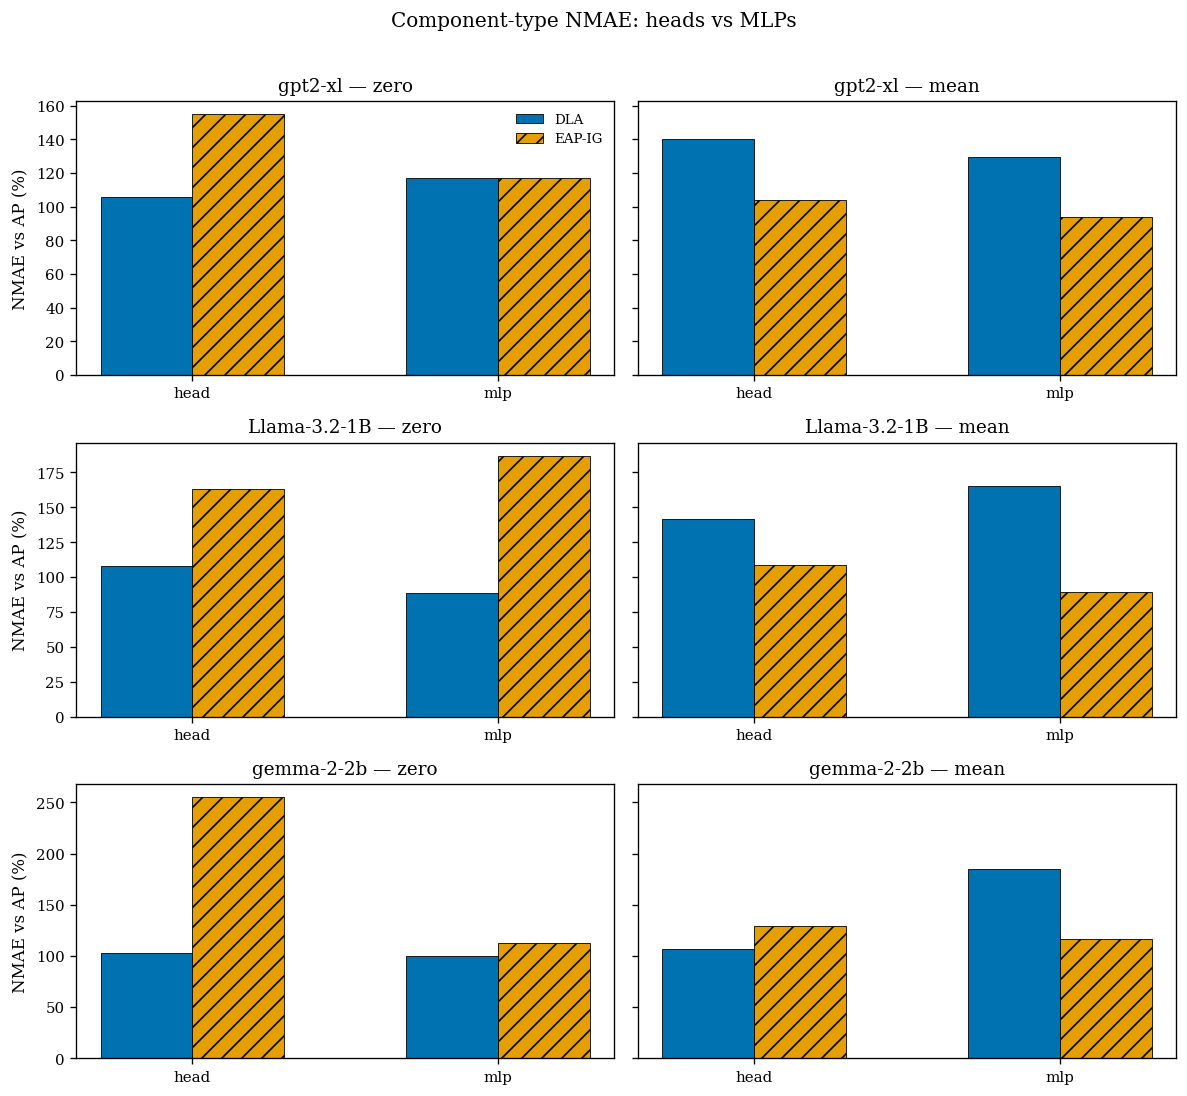

In [13]:
# Section 8 — Heads vs MLPs NMAE breakdown
n_models = len(MODELS)
fig, axes = plt.subplots(n_models, 2, figsize=(10, 3 * n_models), sharey="row")
bar_w = 0.30
comp_types = ["head", "mlp"]

for row_i, model in enumerate(MODELS):
    for col_i, mode in enumerate(MODES):
        ax = axes[row_i, col_i]
        key = (model, mode)
        if key not in record_dfs:
            ax.set_visible(False)
            continue
        df = record_dfs[key]
        ap = df["ap_precap"]
        x = np.arange(len(comp_types))

        for j, method in enumerate(METHODS):
            attr_col = "dla" if method == "DLA" else "eap_ig"
            vals = []
            for ct in comp_types:
                mask = df["component_type"] == ct
                vals.append(nmae_against(
                    df.loc[mask, attr_col].values,
                    ap[mask].values,
                    ap[mask].values,
                ))
            ax.bar(x + j * bar_w, vals, bar_w,
                   color=METHOD_COLORS[method],
                   hatch=METHOD_HATCHES[method],
                   edgecolor="black", linewidth=0.5,
                   label=method)

        ax.set_xticks(x + bar_w / 2)
        ax.set_xticklabels(comp_types)
        ax.set_title(f"{MODEL_SHORT[model]} — {mode}")
        if col_i == 0:
            ax.set_ylabel("NMAE vs AP (%)")
        if row_i == 0 and col_i == 0:
            ax.legend(frameon=False, fontsize=8)

fig.suptitle("Component-type NMAE: heads vs MLPs", fontsize=12, y=1.01)
fig.tight_layout()
save(fig, "fig_component_type.pdf")
plt.show()

## 9. Top-k component agreement

  -> ../../outputs/figures/eap_ig_comparison/fig_topk_agreement.pdf


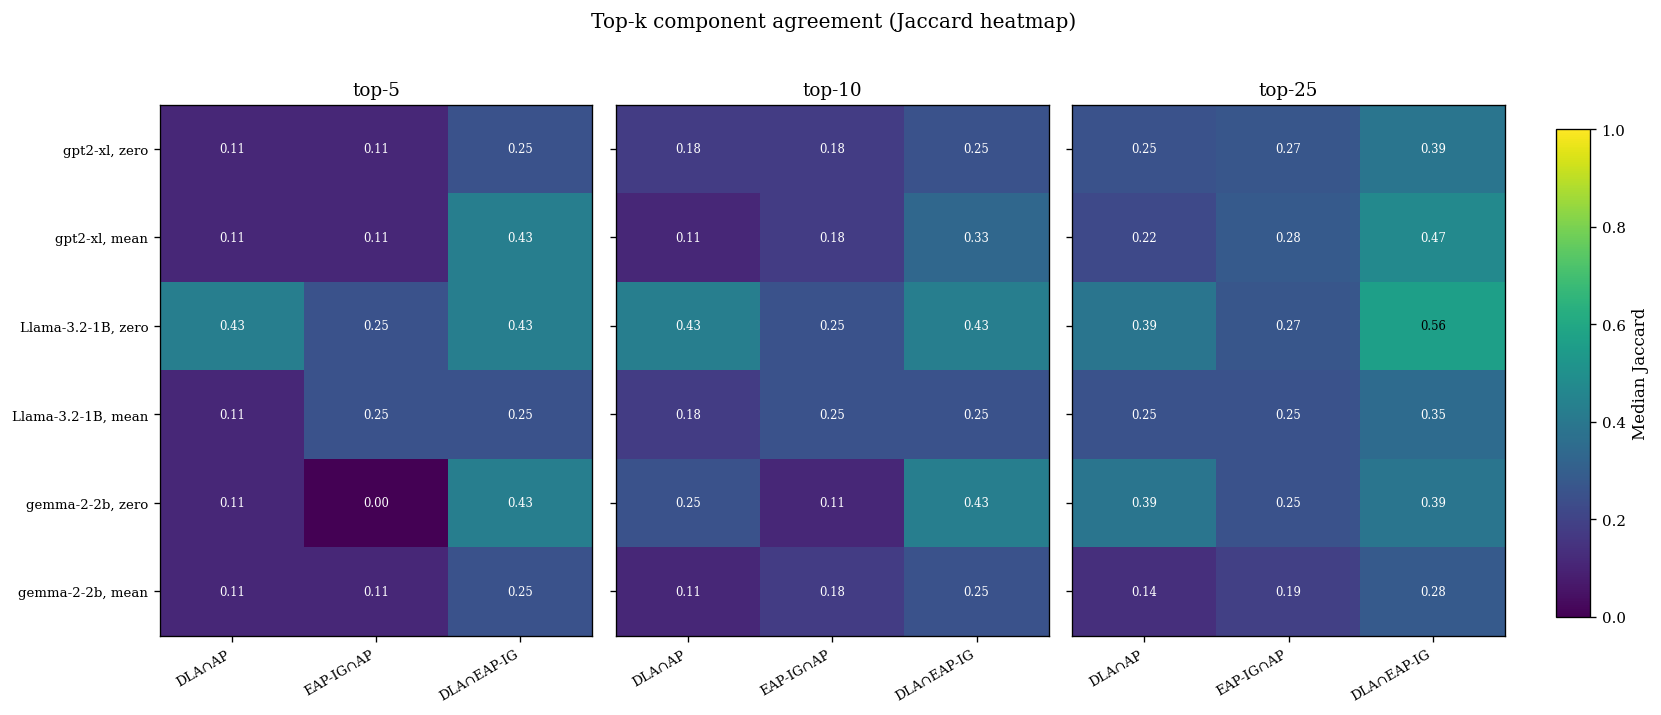

In [14]:
# Section 9 — Top-k component agreement heatmap
from itertools import product as iprod

ks = [5, 10, 25]
method_pairs = [("DLA", "AP"), ("EAP-IG", "AP"), ("DLA", "EAP-IG")]
col_map = {"DLA": "dla", "EAP-IG": "eap_ig", "AP": "ap_precap"}

configs = list(iprod(MODELS, MODES))
pair_labels = [f"{a}∩{b}" for a, b in method_pairs]

fig, axes = plt.subplots(1, len(ks), figsize=(14, 4 + 0.3 * len(configs)), sharey=True)

for k_i, k in enumerate(ks):
    ax = axes[k_i]
    matrix = np.zeros((len(configs), len(method_pairs)))
    ylabels = []

    for r, (model, mode) in enumerate(configs):
        ylabels.append(f"{MODEL_SHORT[model]}, {mode}")
        key = (model, mode)
        if key not in record_dfs:
            matrix[r, :] = np.nan
            continue
        df = record_dfs[key]
        example_ids = df["example_id"].unique()
        pair_jaccards = {p: [] for p in range(len(method_pairs))}

        for eid in example_ids:
            edf = df[df["example_id"] == eid]
            for p, (ma, mb) in enumerate(method_pairs):
                col_a, col_b = col_map[ma], col_map[mb]
                top_a = set(edf.nlargest(k, col_a).index)
                top_b = set(edf.nlargest(k, col_b).index)
                jacc = len(top_a & top_b) / len(top_a | top_b) if top_a | top_b else 0
                pair_jaccards[p].append(jacc)

        for p in range(len(method_pairs)):
            matrix[r, p] = np.median(pair_jaccards[p])

    im = ax.imshow(matrix, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(pair_labels)))
    ax.set_xticklabels(pair_labels, fontsize=8, rotation=30, ha="right")
    ax.set_yticks(range(len(ylabels)))
    if k_i == 0:
        ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_title(f"top-{k}")

    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            v = matrix[r, c]
            if not np.isnan(v):
                ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=7,
                        color="black" if v > 0.5 else "white")

fig.suptitle("Top-k component agreement (Jaccard heatmap)", fontsize=12, y=1.02)
fig.tight_layout(rect=[0, 0, 0.91, 1])
# Dedicated colorbar axis placed outside all heatmap panels (avoids
# overlapping the rightmost panel, which happened with ax=axes shrink=).
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Median Jaccard")
save(fig, "fig_topk_agreement.pdf")
plt.show()

## 11. Paper-ready summary table

In [15]:
# Section 11 — Paper-ready summary table
rows = []
for model in MODELS:
    for mode in MODES:
        erow = eap_summary_df[
            (eap_summary_df["model"] == model)
            & (eap_summary_df["ablation_type"] == mode)
        ].iloc[0]
        drow = dla_summary_df[
            (dla_summary_df["model"] == model)
            & (dla_summary_df["ablation_type"] == mode)
        ].iloc[0]

        nmae_dla = drow["total_dla_error_nmae"]
        nmae_eap = erow["eap_ig_vs_ap_nmae"]
        spear_dla = erow["dla_spearman_median"]
        spear_eap = erow["eap_ig_spearman_median"]
        j5_dla = erow["dla_top5_jaccard_median"]
        j5_eap = erow["eap_ig_top5_jaccard_median"]

        delta_rho = erow.get("delta_spearman_median", spear_eap - spear_dla)
        ci_lo = erow.get("delta_spearman_ci_lo", float("nan"))
        ci_hi = erow.get("delta_spearman_ci_hi", float("nan"))
        pval = erow.get("delta_spearman_pvalue", float("nan"))

        rows.append({
            "Model": MODEL_SHORT[model],
            "Mode": mode,
            "NMAE_DLA": nmae_dla,
            "NMAE_EAP-IG": nmae_eap,
            "ΔNMAE": nmae_eap - nmae_dla,
            "ρ_DLA": spear_dla,
            "ρ_EAP-IG": spear_eap,
            "Δρ": delta_rho,
            "Δρ 95% CI": f"[{ci_lo:+.4f}, {ci_hi:+.4f}]",
            "p": pval,
            "J5_DLA": j5_dla,
            "J5_EAP-IG": j5_eap,
        })

table_df = pd.DataFrame(rows).set_index(["Model", "Mode"])
col_fmt = {c: "{:.3f}" for c in table_df.columns if c not in ("Δρ 95% CI",)}
col_fmt["Δρ 95% CI"] = "{}"
col_fmt["p"] = "{:.4f}"
display(table_df.style.format(col_fmt).highlight_min(
    subset=["NMAE_DLA", "NMAE_EAP-IG"], axis=1, props="font-weight:bold"
).highlight_max(
    subset=["ρ_DLA", "ρ_EAP-IG"], axis=1, props="font-weight:bold"
).highlight_max(
    subset=["J5_DLA", "J5_EAP-IG"], axis=1, props="font-weight:bold"
))

# ── Export CSV ──
table_path = FIG_DIR / "table_headline.csv"
table_df.to_csv(table_path)
print(f"  -> {table_path}")

# ── Export LaTeX ──
def _bold_winner_nmae(row):
    """LaTeX-bold the lower NMAE and higher ρ / Jaccard, format all values."""
    r = {}
    r["Model"] = row["Model"]
    r["Mode"] = row["Mode"]

    fmt3 = lambda v: f"{v:.3f}"
    fmt2 = lambda v: f"{v:.2f}"
    fmt4 = lambda v: f"{v:.4f}"
    bfmt3 = lambda v: f"\\textbf{{{v:.3f}}}"
    bfmt2 = lambda v: f"\\textbf{{{v:.2f}}}"

    if row["NMAE_DLA"] < row["NMAE_EAP-IG"]:
        r["NMAE_DLA"] = bfmt2(row["NMAE_DLA"])
        r["NMAE_EAP-IG"] = fmt2(row["NMAE_EAP-IG"])
    else:
        r["NMAE_DLA"] = fmt2(row["NMAE_DLA"])
        r["NMAE_EAP-IG"] = bfmt2(row["NMAE_EAP-IG"])
    r["ΔNMAE"] = fmt2(row["ΔNMAE"])

    if row["ρ_DLA"] > row["ρ_EAP-IG"]:
        r["ρ_DLA"] = bfmt3(row["ρ_DLA"])
        r["ρ_EAP-IG"] = fmt3(row["ρ_EAP-IG"])
    else:
        r["ρ_DLA"] = fmt3(row["ρ_DLA"])
        r["ρ_EAP-IG"] = bfmt3(row["ρ_EAP-IG"])
    r["Δρ"] = fmt3(row["Δρ"])
    r["Δρ 95\\% CI"] = row["Δρ 95% CI"]
    r["p"] = fmt4(row["p"])

    if row["J5_DLA"] > row["J5_EAP-IG"]:
        r["J5_DLA"] = bfmt3(row["J5_DLA"])
        r["J5_EAP-IG"] = fmt3(row["J5_EAP-IG"])
    else:
        r["J5_DLA"] = fmt3(row["J5_DLA"])
        r["J5_EAP-IG"] = bfmt3(row["J5_EAP-IG"])
    return pd.Series(r)

tex_df = table_df.reset_index().apply(_bold_winner_nmae, axis=1)
tex_df = tex_df.set_index(["Model", "Mode"])
tex_path = FIG_DIR / "table_headline.tex"
tex_df.to_latex(tex_path, escape=False, multirow=True,
                caption="Headline comparison: DLA vs EAP-IG against AP ground truth.",
                label="tab:headline")
print(f"  -> {tex_path}")

print("\nDone — all figures and tables exported.")

  -> ../../outputs/figures/eap_ig_comparison/table_headline.csv
  -> ../../outputs/figures/eap_ig_comparison/table_headline.tex

Done — all figures and tables exported.
